In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pedestrian-detection/Val/Val/val.txt
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (123).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (97).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (67).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (55).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (36).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (137).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (71).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (129).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (47).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (79).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (96).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (9).xml
/kaggle/input/pedestrian-detection/Val/Val/Annotations/image (43).xml
/kaggle/input/pedestrian-detection/Va

In [6]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 90.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.1 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [25]:
import os

print("--- محتويات الـ Input بالتفصيل ---")

# هيمشي في كل الفولدرات ويقولنا لقى إيه
for root, dirs, files in os.walk('/kaggle/input'):
    # اطبع اسم الفولدر الحالي
    print(f"\n📂 المجلد: {root}")
    
    # اطبع أول 5 ملفات جواه عشان نعرف نوعها
    if len(files) > 0:
        print(f"   📄 أمثلة للملفات: {files[:5]}")
        
        # فحص سريع: هل دي ملفات YOLO؟
        if any(f.endswith('.txt') for f in files):
            print("   ✅ (لقيت ملفات Text! احتمال تكون YOLO)")
        elif any(f.endswith('.json') for f in files):
            print("   ⚠️ (لقيت ملفات JSON.. دي غالباً Segmentation مش YOLO)")
        elif any(f.endswith('.xml') for f in files):
            print("   ⚠️ (لقيت ملفات XML.. دي محتاجة تحويل)")
    
    # عشان ما يطبعش كتير، كفاية أول 3 مستويات
    if root.count(os.sep) - '/kaggle/input'.count(os.sep) > 2:
        break
        

--- محتويات الـ Input بالتفصيل ---

📂 المجلد: /kaggle/input

📂 المجلد: /kaggle/input/indian-driving-dataset-detections-yolov11

📂 المجلد: /kaggle/input/indian-driving-dataset-detections-yolov11/IDDDetectionsYOLODataset
   📄 أمثلة للملفات: ['license.md', 'ReadMe.md', 'data.yaml']

📂 المجلد: /kaggle/input/indian-driving-dataset-detections-yolov11/IDDDetectionsYOLODataset/val


In [31]:
import os

print("--- استكشاف هيكل داتا الحفر ---")
pothole_path = '/kaggle/input/pothole-detection'

found_any_label = False

for root, dirs, files in os.walk(pothole_path):
    # طباعة اسم الفولدر الحالي
    print(f"\n📂 المجلد: {root}")
    
    # طباعة أول 5 ملفات
    if files:
        print(f"   📄 عينة ملفات: {files[:5]}")
        
        # بنشوف هل فيه أي ملفات Labels (xml أو txt)
        xmls = [f for f in files if f.endswith('.xml')]
        txts = [f for f in files if f.endswith('.txt')]
        
        if xmls:
            print(f"      ✅ لقينا {len(xmls)} ملف XML هنا!")
            found_any_label = True
        if txts:
            print(f"      ✅ لقينا {len(txts)} ملف TXT هنا!")
            found_any_label = True

if not found_any_label:
    print("\n⚠️ كارثة: مفيش ولا ملف ليبل (XML ولا TXT) في الداتا دي كلها!")
    print("غالباً الداتا دي صور بس، أو الليبلز في ملف CSV واحد.")

--- استكشاف هيكل داتا الحفر ---

📂 المجلد: /kaggle/input/pothole-detection

📂 المجلد: /kaggle/input/pothole-detection/annotations
   📄 عينة ملفات: ['potholes101.xml', 'potholes143.xml', 'potholes325.xml', 'potholes17.xml', 'potholes64.xml']
      ✅ لقينا 665 ملف XML هنا!

📂 المجلد: /kaggle/input/pothole-detection/images
   📄 عينة ملفات: ['potholes28.png', 'potholes133.png', 'potholes230.png', 'potholes246.png', 'potholes648.png']


In [32]:
import os
import shutil
import yaml
import random
import cv2
import xml.etree.ElementTree as ET
from tqdm.notebook import tqdm

# ================= مسارات الداتا (بناءً على استكشافك) =================
# 1. داتا الحفر
pothole_img_dir = '/kaggle/input/pothole-detection/images'
pothole_ann_dir = '/kaggle/input/pothole-detection/annotations'

# 2. داتا الهند
idd_path = '/kaggle/input/indian-driving-dataset-detections-yolov11/IDDDetectionsYOLODataset'

# المسار النهائي
output_dir = '/kaggle/working/final_dataset'
# ======================================================================

# دالة تحويل الـ XML لـ YOLO (السر كله هنا)
def convert_annotation(xml_file, img_width, img_height):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    yolo_lines = []
    
    for obj in root.findall('object'):
        # تحويل الإحداثيات من (xmin, ymin) لـ (x_center, y_center, w, h)
        bndbox = obj.find('bndbox')
        xmin = float(bndbox.find('xmin').text)
        ymin = float(bndbox.find('ymin').text)
        xmax = float(bndbox.find('xmax').text)
        ymax = float(bndbox.find('ymax').text)
        
        # معادلات YOLO
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        w = (xmax - xmin) / img_width
        h = (ymax - ymin) / img_height
        
        # الكلاس 1 (Pothole)
        yolo_lines.append(f"1 {x_center} {y_center} {w} {h}")
        
    return yolo_lines

# تنظيف وتجهيز
if os.path.exists(output_dir): shutil.rmtree(output_dir)
for split in ['train', 'val']:
    os.makedirs(f"{output_dir}/{split}/images", exist_ok=True)
    os.makedirs(f"{output_dir}/{split}/labels", exist_ok=True)

print("🚀 بدأنا الدمج (المحاولة الصحيحة)...")

# ---------------------------------------------------------
# 1. معالجة الحفر (Potholes)
# ---------------------------------------------------------
print("\n1️⃣ جاري تحويل الحفر من XML لـ YOLO...")
pothole_files = [f for f in os.listdir(pothole_img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

count_potholes = 0
for i, filename in enumerate(tqdm(pothole_files)):
    split = 'train' if i < (len(pothole_files) * 0.8) else 'val'
    
    # 1. قراءة الصورة عشان نعرف أبعادها (مهم للتحويل)
    img_src = os.path.join(pothole_img_dir, filename)
    img = cv2.imread(img_src)
    if img is None: continue
    height, width, _ = img.shape
    
    # 2. البحث عن ملف الـ XML المقابل
    xml_filename = os.path.splitext(filename)[0] + '.xml'
    xml_src = os.path.join(pothole_ann_dir, xml_filename)
    
    if os.path.exists(xml_src):
        # تحويل الإحداثيات
        yolo_data = convert_annotation(xml_src, width, height)
        
        if yolo_data:
            # نسخ الصورة
            shutil.copy(img_src, f"{output_dir}/{split}/images/pot_{filename}")
            
            # حفظ الليبل الجديد (txt)
            txt_filename = os.path.splitext(filename)[0] + '.txt'
            with open(f"{output_dir}/{split}/labels/pot_{txt_filename}", 'w') as f:
                f.write("\n".join(yolo_data))
            
            count_potholes += 1

print(f"   -> تم بنجاح تحويل {count_potholes} صورة حفر.")

# ---------------------------------------------------------
# 2. معالجة المشاة من الهند (زي ما هي)
# ---------------------------------------------------------
print("\n2️⃣ جاري نقل المشاة من الهند...")
with open(f'{idd_path}/data.yaml', 'r') as f:
    idd_data = yaml.safe_load(f)
    names = idd_data['names']

target_ids = []
if isinstance(names, list):
    for i, name in enumerate(names):
        if name in ['person', 'rider']: target_ids.append(i)
elif isinstance(names, dict):
    for k, v in names.items():
        if v in ['person', 'rider']: target_ids.append(k)

idd_images = []
for root, dirs, files in os.walk(idd_path):
    for f in files:
        if f.endswith('.jpg'): idd_images.append(os.path.join(root, f))

random.shuffle(idd_images)
selected_idd = idd_images[:1500] 

count_people = 0
for i, img_path in enumerate(tqdm(selected_idd)):
    split = 'train' if i < (len(selected_idd) * 0.8) else 'val'
    lbl_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
    
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f: lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.split()
            if parts and int(parts[0]) in target_ids:
                parts[0] = '0' 
                new_lines.append(" ".join(parts) + "\n")
        
        if new_lines:
            fname = os.path.basename(img_path)
            shutil.copy(img_path, f"{output_dir}/{split}/images/ind_{fname}")
            with open(f"{output_dir}/{split}/labels/ind_{os.path.splitext(fname)[0]}.txt", 'w') as f:
                f.writelines(new_lines)
            count_people += 1

print(f"\n✅ النتيجة النهائية:")
print(f"🔥 عدد الحفر (Class 1): {count_potholes}")
print(f"🚶 عدد المشاة (Class 0): {count_people}")

🚀 بدأنا الدمج (المحاولة الصحيحة)...

1️⃣ جاري تحويل الحفر من XML لـ YOLO...


  0%|          | 0/665 [00:00<?, ?it/s]

   -> تم بنجاح تحويل 665 صورة حفر.

2️⃣ جاري نقل المشاة من الهند...


  0%|          | 0/1500 [00:00<?, ?it/s]


✅ النتيجة النهائية:
🔥 عدد الحفر (Class 1): 665
🚶 عدد المشاة (Class 0): 1134


In [33]:
import yaml

# إعدادات الداتا النهائية
config = {
    'path': '/kaggle/working/final_dataset', 
    'train': 'train/images',
    'val': 'val/images',
    'nc': 2,                       # عدد الكلاسات
    'names': ['Pedestrian', 'Pothole'] # الأسماء بالترتيب (0, 1)
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(config, f)

print("ملف data.yaml جاهز! 🏎️")

ملف data.yaml جاهز! 🏎️


In [34]:
from ultralytics import YOLO
import torch

# تحميل الموديل
model = YOLO('yolov8n.pt') 

# بدء التدريب
results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=30,                        # 30 لفة كافية جداً
    imgsz=640,
    batch=16,
    project='Egypt_Road_Safety',      # اسم المشروع
    name='Final_Model_v1',            # اسم الموديل النهائي
    device=0,
    verbose=True
)

Ultralytics 8.3.232 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=Final_Model_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        358       1750      0.757      0.542      0.625       0.37
            Pedestrian        225       1395       0.77      0.349       0.45      0.232
               Pothole        133        355      0.744      0.735        0.8      0.507
Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/Egypt_Road_Safety/Final_Model_v1


عدد صور الاختبار المتاحة: 358

image 1/1 /kaggle/working/final_dataset/val/images/ind_BLR-2018-04-25_09-35-06_frontNear_left_0004410.jpg: 384x640 4 Pedestrians, 7.3ms
Speed: 2.0ms preprocess, 7.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/working/final_dataset/val/images/ind_BLR-2018-04-19_18-06-55_frontFar_000588_r.jpg: 512x640 3 Pedestrians, 34.6ms
Speed: 2.0ms preprocess, 34.6ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /kaggle/working/final_dataset/val/images/pot_potholes26.png: 480x640 (no detections), 7.1ms
Speed: 1.7ms preprocess, 7.1ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /kaggle/working/final_dataset/val/images/ind_BLR-2018-05-03_14-26-52_sideLeft_left_0009192.jpg: 384x640 5 Pedestrians, 6.8ms
Speed: 1.7ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


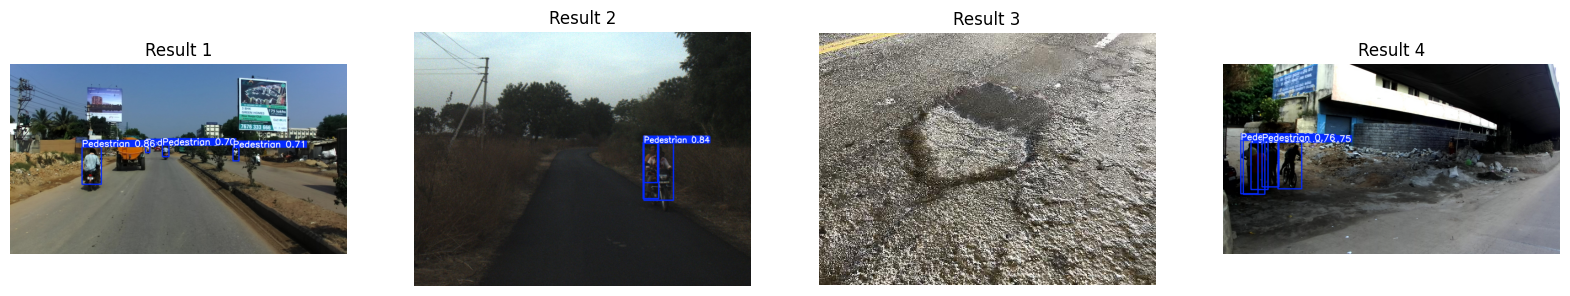

In [46]:
from ultralytics import YOLO
import glob
import random
import cv2
import matplotlib.pyplot as plt

# 1. تحميل الموديل النهائي (أذكى نسخة)
model_path = '/kaggle/working/Egypt_Road_Safety/Final_Model_v1/weights/best.pt'
model = YOLO(model_path)

# 2. اختيار صور عشوائية من الـ Validation
# هندور على صور الحفر وصور الهند
val_images = glob.glob('/kaggle/working/final_dataset/val/images/*.jpg') + \
             glob.glob('/kaggle/working/final_dataset/val/images/*.png')

print(f"عدد صور الاختبار المتاحة: {len(val_images)}")

# عرض 4 صور عشوائية
if len(val_images) > 0:
    plt.figure(figsize=(20, 10))
    
    # نختار 4 صور عشوائية
    selected_images = random.sample(val_images, min(4, len(val_images)))
    
    for i, img_path in enumerate(selected_images):
        # تشغيل الموديل
        results = model.predict(img_path, conf=0.25) # conf=0.25 ثقة متوسطة
        
        # رسم النتيجة
        result_array = results[0].plot()
        
        # تظبيط الألوان
        result_array = cv2.cvtColor(result_array, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 4, i+1)
        plt.imshow(result_array)
        plt.axis('off')
        plt.title(f"Result {i+1}")

    plt.show()
else:
    print("مش لاقي صور في الـ val!")

عدد صور الاختبار: 358

image 1/1 /kaggle/working/final_dataset/val/images/pot_potholes506.png: 640x640 4 Potholes, 7.3ms
Speed: 2.0ms preprocess, 7.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/final_dataset/val/images/ind_BLR-2018-04-19_18-16-55_sideRight_000168_r.jpg: 384x640 2 Pedestrians, 6.9ms
Speed: 1.7ms preprocess, 6.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/working/final_dataset/val/images/ind_BLR-2018-04-19_18-06-55_frontFar_0005700.jpg: 512x640 (no detections), 6.8ms
Speed: 1.8ms preprocess, 6.8ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

image 1/1 /kaggle/working/final_dataset/val/images/pot_potholes538.png: 480x640 3 Potholes, 6.8ms
Speed: 1.7ms preprocess, 6.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /kaggle/working/final_dataset/val/images/ind_BLR-2018-04-26_13-00-01_sideLeft_0001080.jpg: 384x640 (no detections), 6.9

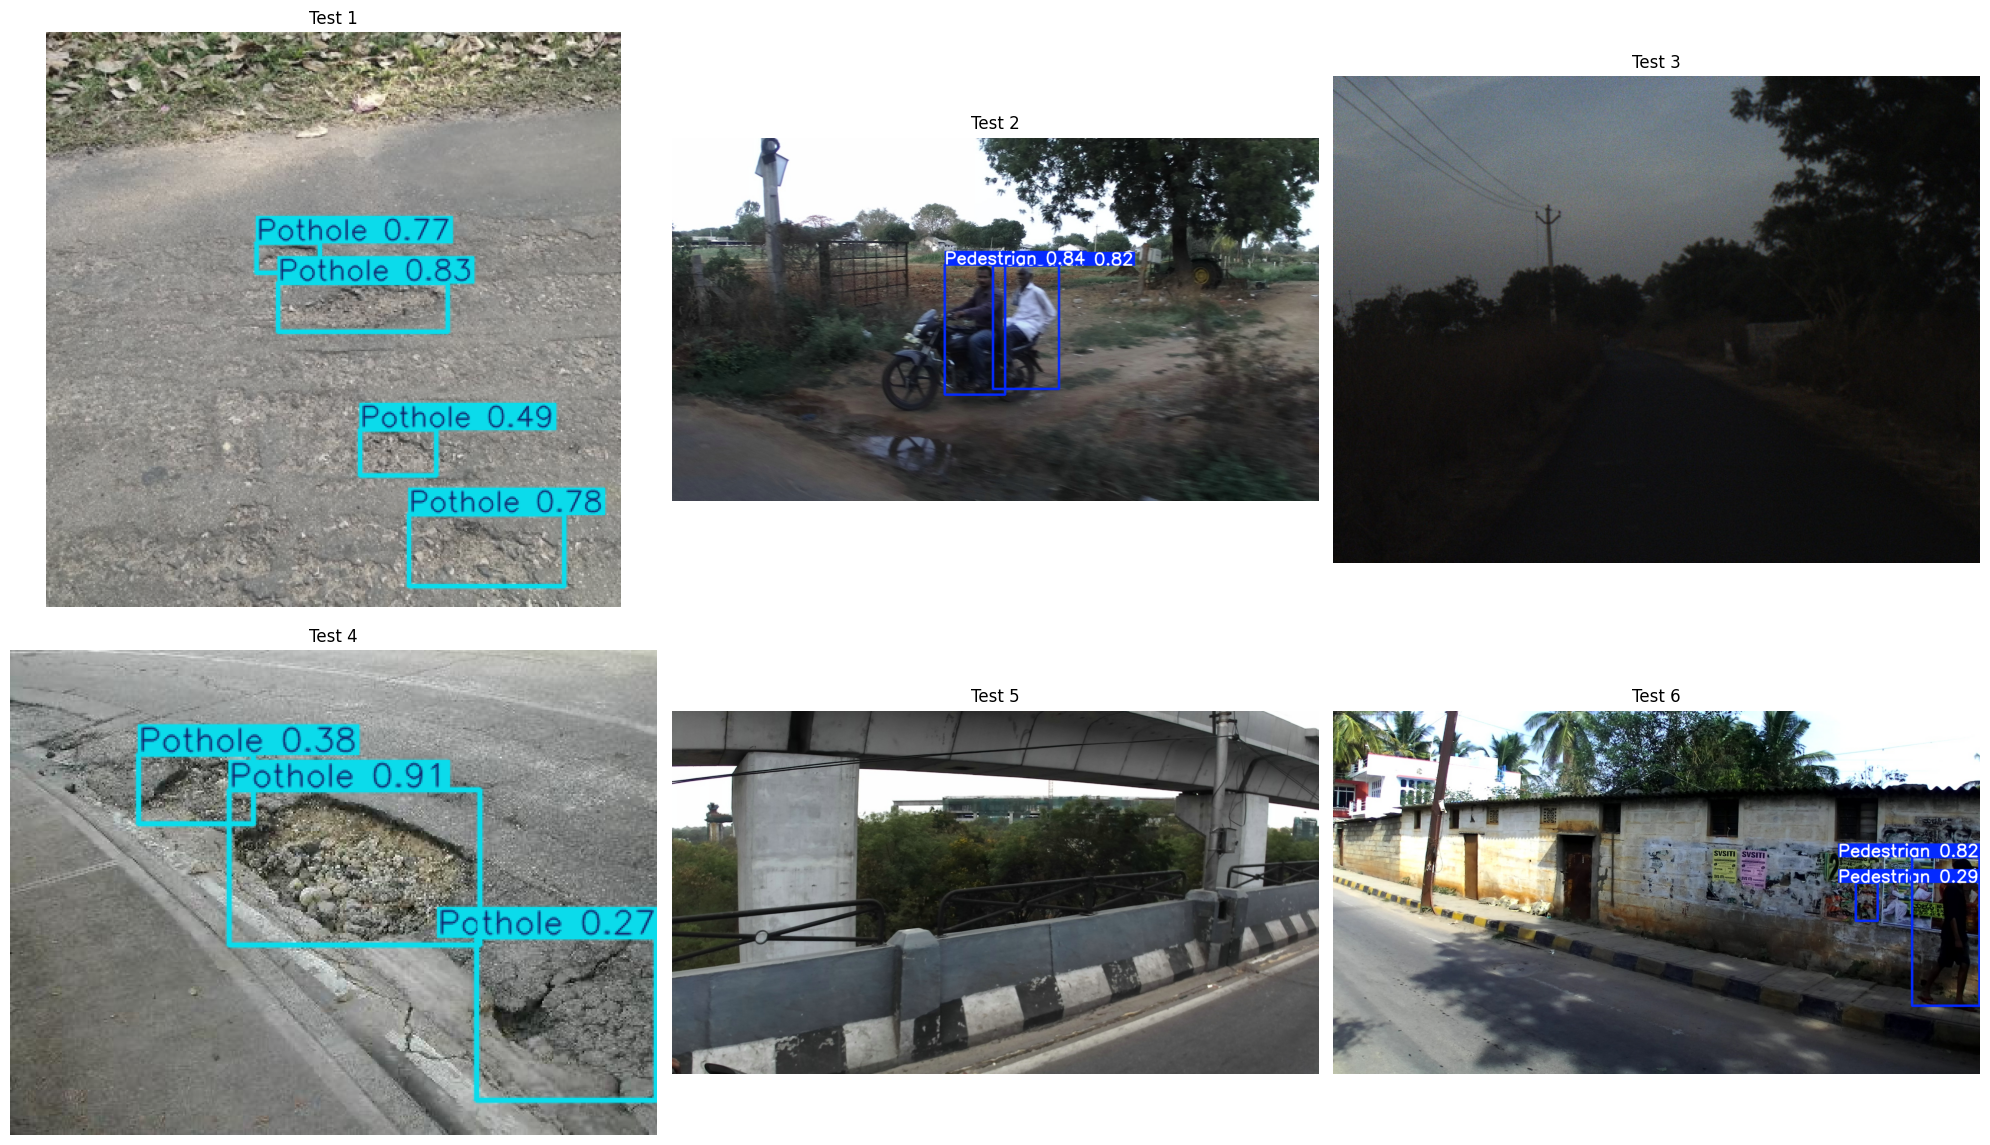

In [51]:
from ultralytics import YOLO
import glob
import random
import cv2
import matplotlib.pyplot as plt

# تحميل الموديل الناجح
model = YOLO('/kaggle/working/Egypt_Road_Safety/Final_Model_v1/weights/best.pt')

# هنجيب صور من الـ Validation (اللي الموديل بيمتحن عليها)
# هندور في فولدرات الصور (الهند + الحفر)
test_images = glob.glob('/kaggle/working/final_dataset/val/images/*.jpg') + \
              glob.glob('/kaggle/working/final_dataset/val/images/*.png')

print(f"عدد صور الاختبار: {len(test_images)}")

if len(test_images) > 0:
    plt.figure(figsize=(20, 12))
    
    # نختار 6 صور عشوائية
    samples = random.sample(test_images, min(6, len(test_images)))
    
    for i, img_path in enumerate(samples):
        # conf=0.25 (يعني لو شاكك بنسبة 25% ارسم المربع)
        results = model.predict(img_path, conf=0.25)
        
        # رسم النتيجة
        res_plot = results[0].plot()
        res_plot = cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 3, i+1)
        plt.imshow(res_plot)
        plt.axis('off')
        plt.title(f"Test {i+1}")
        
    plt.tight_layout()
    plt.show()